V1S1:
  Total spots: 648
  Spots with neighbors: 648
  Isolated spots: 0 (0.0%)
  Mean neighbors: 5.7

V1S2:
  Total spots: 620
  Spots with neighbors: 620
  Isolated spots: 0 (0.0%)
  Mean neighbors: 5.7

V1S1:
  [1/60] CD8-Tcell_naive - Myeloid_DC2... done
  [2/60] CD8-Tcell_naive - Myeloid_Macrophage... done
  [3/60] CD8-Tcell_naive - Myeloid_Macrophage-CXCL9/10... done
  [4/60] CD8-Tcell_naive - Myeloid_cDC1... done
  [5/60] CD8-Tcell_naive - Myeloid_marginalzone... done
  [6/60] CD8-Tcell_naive - Myeloid_migratory... done
  [7/60] CD8-Tcell_naive - Myeloid_moDC... done
  [8/60] CD8-Tcell_naive - Myeloid_moDC-CXCL9/10... done
  [9/60] CD8-Tcell_naive - Myeloid_monocyte... done
  [10/60] CD8-Tcell_naive - Myeloid_pDC... done
  [11/60] CD8-Tcell_early-active - Myeloid_DC2... done
  [12/60] CD8-Tcell_early-active - Myeloid_Macrophage... done
  [13/60] CD8-Tcell_early-active - Myeloid_Macrophage-CXCL9/10... done
  [14/60] CD8-Tcell_early-active - Myeloid_cDC1... done
  [15/60] CD8-Tcel

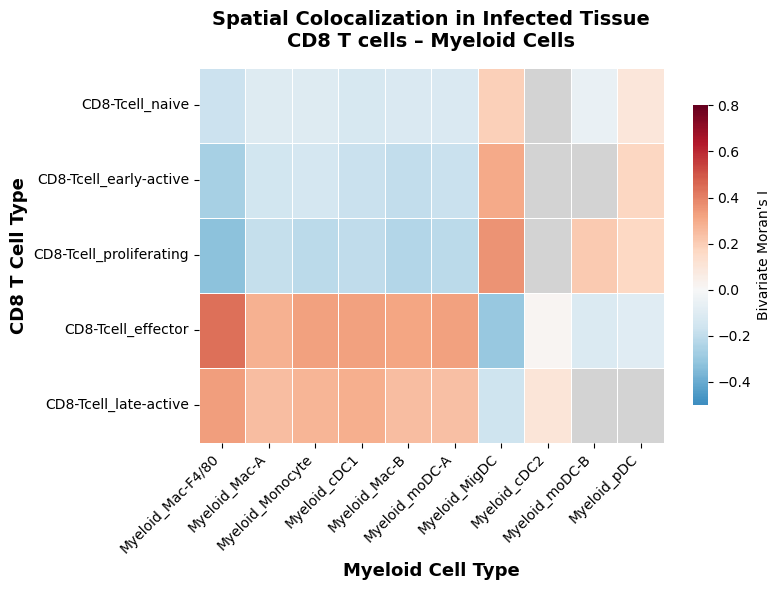

💾 Saved: global_morans_i_corrected.csv

COMPLETE - GLOBAL ANALYSIS WITH CORRECTED SPATIAL NEIGHBORS


: 

In [ ]:
from esda.moran import Moran_BV
from libpysal.weights import W
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc


infected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad'
adata_infected = sc.read_h5ad(infected_path)


conventional_cd8 = [
    'CD8-Tcell_naive',
    'CD8-Tcell_early-active', 
    'CD8-Tcell_effector',
    'CD8-Tcell_late-active',
    'CD8-Tcell_terminal',
    'CD8-Tcell_proliferating'
]

myeloid_types = [ct for ct in adata_infected.obsm['means_cell_abundance_w_sf'].columns 
                 if 'Myeloid' in ct]

name_mapping = {
    'Myeloid_DC2': 'Myeloid_cDC2',
    'Myeloid_Macrophage': 'Myeloid_Mac-A',
    'Myeloid_Macrophage-CXCL9/10': 'Myeloid_Mac-B',
    'Myeloid_cDC1': 'Myeloid_cDC1',
    'Myeloid_marginalzone': 'Myeloid_Mac-F4/80',
    'Myeloid_migratory': 'Myeloid_MigDC',
    'Myeloid_moDC': 'Myeloid_moDC-A',
    'Myeloid_moDC-CXCL9/10': 'Myeloid_moDC-B',
    'Myeloid_monocyte': 'Myeloid_Monocyte',
    'Myeloid_pDC': 'Myeloid_pDC',
}



def create_distance_based_weights(coords, radius=300):
    """
    Create spatial weights based on distance threshold
    radius: maximum distance for neighbors (in coordinate units)
    """
    n_spots = coords.shape[0]
    
    # Use ball tree for efficient radius search
    nbrs = NearestNeighbors(radius=radius, algorithm='ball_tree').fit(coords)
    distances, indices = nbrs.radius_neighbors(coords)
    
    # Build W object
    neighbors = {}
    weights_dict = {}
    
    for i in range(n_spots):
        neighbor_idx = indices[i]
        neighbor_dist = distances[i]
        
        # Remove self
        mask = neighbor_idx != i
        neighbor_idx = neighbor_idx[mask]
        neighbor_dist = neighbor_dist[mask]
        
        if len(neighbor_idx) > 0:
            # Weight by inverse distance
            weights = 1.0 / (neighbor_dist + 1e-10)
            
            neighbors[i] = neighbor_idx.tolist()
            weights_dict[i] = weights.tolist()
    
    w = W(neighbors, weights_dict)
    return w

weights_dict = {}
indices_dict = {}

for sample in ['V1S1', 'V1S2']:
    mask = (adata_infected.obs['sample'] == sample).values
    indices = np.where(mask)[0]
    coords = adata_infected.obsm['spatial'][mask]
    
    w = create_distance_based_weights(coords, radius=300)
    weights_dict[sample] = w
    indices_dict[sample] = indices
    
    # Check isolation
    n_isolated = sum(1 for i in range(len(indices)) if i not in w.neighbors)
    pct_isolated = (n_isolated / len(indices)) * 100
    
    print(f"{sample}:")
    print(f"  Total spots: {len(indices)}")
    print(f"  Spots with neighbors: {w.n}")
    print(f"  Isolated spots: {n_isolated} ({pct_isolated:.1f}%)")
    print(f"  Mean neighbors: {w.mean_neighbors:.1f}")
    print()

all_results = []

for sample in ['V1S1', 'V1S2']:
    print(f"{sample}:")
    
    indices = indices_dict[sample]
    abundances = adata_infected.obsm['means_cell_abundance_w_sf'].iloc[indices]
    w = weights_dict[sample]
    
    # Only use spots that have neighbors
    connected_spots = list(w.neighbors.keys())
    abundances_connected = abundances.iloc[connected_spots]
    
    pair_count = 0
    total_pairs = len(conventional_cd8) * len(myeloid_types)
    
    for cd8 in conventional_cd8:
        for myeloid in myeloid_types:
            pair_count += 1
            print(f"  [{pair_count}/{total_pairs}] {cd8} - {myeloid}...", end="")
            
            try:
                x = abundances_connected[cd8].values.astype(np.float64)
                y = abundances_connected[myeloid].values.astype(np.float64)
                
                if x.std() == 0 or y.std() == 0:
                    print(" skipped (no variance)")
                    continue
                
                # Global Bivariate Moran's I
                moran_bv = Moran_BV(x, y, w, permutations=9999)
                
                all_results.append({
                    'sample': sample,
                    'condition': 'infected',
                    'cell_type_1': cd8,
                    'cell_type_2': myeloid,
                    'I': moran_bv.I,
                    'p_value': moran_bv.p_sim,
                    'n_spots': len(connected_spots)
                })
                
                print(" done")
                
            except Exception as e:
                print(f" failed: {e}")
                continue
    
    print()

moran_results = pd.DataFrame(all_results)
print(f"✅ Complete! {len(moran_results)} calculations")


# Filter for CD8-Myeloid pairs
cd8_myeloid_raw = moran_results[
    ((moran_results['cell_type_1'].isin(conventional_cd8) & moran_results['cell_type_2'].isin(myeloid_types)) |
     (moran_results['cell_type_2'].isin(conventional_cd8) & moran_results['cell_type_1'].isin(myeloid_types)))
].copy()

# Standardize so CD8 is always in cell_type_1
for idx, row in cd8_myeloid_raw.iterrows():
    if row['cell_type_1'] in myeloid_types:
        cd8_myeloid_raw.at[idx, 'cell_type_1'] = row['cell_type_2']
        cd8_myeloid_raw.at[idx, 'cell_type_2'] = row['cell_type_1']

# Calculate mean across infected samples for both I and p_value
mean_values = cd8_myeloid_raw.groupby(['cell_type_1', 'cell_type_2']).agg(
    I=('I', 'mean'),
    p_value=('p_value', 'mean')
).reset_index()

# Create I matrix
infected_matrix = mean_values.pivot(
    index='cell_type_1', 
    columns='cell_type_2', 
    values='I'
)

# Create p-value matrix (same shape)
pval_matrix = mean_values.pivot(
    index='cell_type_1',
    columns='cell_type_2',
    values='p_value'
)

cd8_row_order = [
    'CD8-Tcell_naive',
    'CD8-Tcell_early-active',
    'CD8-Tcell_proliferating',
    'CD8-Tcell_effector',
    'CD8-Tcell_late-active',
]
infected_matrix = infected_matrix.reindex(cd8_row_order)
pval_matrix = pval_matrix.reindex(cd8_row_order)

# Rename to paper names (only applies to columns since rows are CD8)
infected_matrix.columns = [name_mapping.get(col, col) for col in infected_matrix.columns]
pval_matrix.columns = [name_mapping.get(col, col) for col in pval_matrix.columns]

# Cluster columns
from scipy.cluster.hierarchy import dendrogram, linkage
valid_cols = infected_matrix.columns[~infected_matrix.isna().all()]
linkage_matrix = linkage(infected_matrix[valid_cols].T.fillna(0), method='average', metric='euclidean')
col_order = valid_cols[dendrogram(linkage_matrix, no_plot=True)['leaves']]
infected_matrix = infected_matrix[col_order]
pval_matrix = pval_matrix[col_order]

# Mask for non-significant associations
ns_mask = pval_matrix >= 0.05

# Create figure
from matplotlib.colors import ListedColormap
fig, ax = plt.subplots(figsize=(8, 6))

# Plot significant cells with RdBu_r
sns.heatmap(
    infected_matrix,
    cmap='RdBu_r',
    center=0,
    vmin=-0.5,
    vmax=0.8,
    mask=ns_mask,
    cbar_kws={'label': "Bivariate Moran's I", 'shrink': 0.8},
    linewidths=0.5,
    linecolor='white',
    square=False,
    ax=ax,
    annot=False,
)

# Overlay non-significant cells in gray
if ns_mask.any().any():
    sns.heatmap(
        infected_matrix,
        mask=~ns_mask,
        cmap=ListedColormap(['#D3D3D3']),
        cbar=False,
        linewidths=0.5,
        linecolor='white',
        square=False,
        ax=ax,
        annot=False,
    )

ax.set_xlabel('Myeloid Cell Type', fontsize=13, fontweight='bold')
ax.set_ylabel('CD8 T Cell Type', fontsize=13, fontweight='bold')
ax.set_title('Spatial Colocalization in Infected Tissue\nCD8 T cells \u2013 Myeloid Cells',
             fontsize=14, fontweight='bold', pad=15)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('cd8_myeloid_colocalization_infected_CORRECTED.png', dpi=300, bbox_inches='tight')
plt.savefig('cd8_myeloid_colocalization_infected_CORRECTED.pdf', bbox_inches='tight')
print("\n📊 Saved: cd8_myeloid_colocalization_infected_CORRECTED.png/pdf")
plt.show()

# Save results
moran_results.to_csv('global_morans_i_corrected.csv', index=False)
print("💾 Saved: global_morans_i_corrected.csv")

print("\n" + "="*80)
print("COMPLETE - GLOBAL ANALYSIS WITH CORRECTED SPATIAL NEIGHBORS")
print("="*80)

In [3]:
# ADD THIS CHECK after line 84 in your create_distance_based_weights function:

# Check if weights are row-normalized (they should be)
print("\n🔍 WEIGHT NORMALIZATION CHECK:")
test_w = create_distance_based_weights(coords[:10], radius=300)

# Check a few rows
for i in list(test_w.neighbors.keys())[:3]:
    weight_sum = sum(test_w.weights[i])
    print(f"Spot {i}: Sum of weights = {weight_sum:.4f}")
    
if not test_w.transform == 'O':  # 'O' means original (not normalized)
    print("⚠️  Weights are NOT row-normalized")
    print("   This is OKAY for Moran's I but check esda docs")
else:
    print("✅ Using original (non-normalized) weights")


🔍 WEIGHT NORMALIZATION CHECK:
✅ Using original (non-normalized) weights


In [4]:
# Check p-values
print("P-values for CD8-Myeloid colocalization:")
print(moran_results[['sample', 'cell_type_1', 'cell_type_2', 'I', 'p_value']].to_string())

print("\n\nSummary:")
print(f"Significant at p < 0.05: {(moran_results['p_value'] < 0.05).sum()}/{len(moran_results)}")
print(f"Significant at p < 0.01: {(moran_results['p_value'] < 0.01).sum()}/{len(moran_results)}")


P-values for CD8-Myeloid colocalization:
    sample              cell_type_1                  cell_type_2         I  p_value
0     V1S1          CD8-Tcell_naive                  Myeloid_DC2 -0.045111   0.0260
1     V1S1          CD8-Tcell_naive           Myeloid_Macrophage -0.131616   0.0001
2     V1S1          CD8-Tcell_naive  Myeloid_Macrophage-CXCL9/10 -0.170320   0.0001
3     V1S1          CD8-Tcell_naive                 Myeloid_cDC1 -0.178292   0.0001
4     V1S1          CD8-Tcell_naive         Myeloid_marginalzone -0.229162   0.0001
5     V1S1          CD8-Tcell_naive            Myeloid_migratory  0.248756   0.0001
6     V1S1          CD8-Tcell_naive                 Myeloid_moDC -0.173312   0.0001
7     V1S1          CD8-Tcell_naive        Myeloid_moDC-CXCL9/10 -0.048694   0.0236
8     V1S1          CD8-Tcell_naive             Myeloid_monocyte -0.160722   0.0001
9     V1S1          CD8-Tcell_naive                  Myeloid_pDC  0.108233   0.0007
10    V1S1   CD8-Tcell_early-active

In [5]:
# Apply FDR correction
from statsmodels.stats.multitest import multipletests

# Correct p-values across all tests
_, moran_results['p_value_fdr'], _, _ = multipletests(
    moran_results['p_value'], 
    method='fdr_bh'
)

# Summary with FDR
print("After FDR correction:")
print(f"Significant at FDR < 0.05: {(moran_results['p_value_fdr'] < 0.05).sum()}/{len(moran_results)}")
print(f"Significant at FDR < 0.01: {(moran_results['p_value_fdr'] < 0.01).sum()}/{len(moran_results)}")

# Show which pairs are still significant
print("\nAll results with FDR:")
print(moran_results[['sample', 'cell_type_1', 'cell_type_2', 'I', 'p_value', 'p_value_fdr']].to_string())

After FDR correction:
Significant at FDR < 0.05: 108/120
Significant at FDR < 0.01: 100/120

All results with FDR:
    sample              cell_type_1                  cell_type_2         I  p_value  p_value_fdr
0     V1S1          CD8-Tcell_naive                  Myeloid_DC2 -0.045111   0.0260     0.030000
1     V1S1          CD8-Tcell_naive           Myeloid_Macrophage -0.131616   0.0001     0.000136
2     V1S1          CD8-Tcell_naive  Myeloid_Macrophage-CXCL9/10 -0.170320   0.0001     0.000136
3     V1S1          CD8-Tcell_naive                 Myeloid_cDC1 -0.178292   0.0001     0.000136
4     V1S1          CD8-Tcell_naive         Myeloid_marginalzone -0.229162   0.0001     0.000136
5     V1S1          CD8-Tcell_naive            Myeloid_migratory  0.248756   0.0001     0.000136
6     V1S1          CD8-Tcell_naive                 Myeloid_moDC -0.173312   0.0001     0.000136
7     V1S1          CD8-Tcell_naive        Myeloid_moDC-CXCL9/10 -0.048694   0.0236     0.027495
8     V1S1  